In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(sys.executable)

c:\Users\Lenovo\Desktop\projects_GitHub\fitness-calories-eda\venv\Scripts\python.exe


In [2]:
df = pd.read_csv("../data/processed/cleaned_data.csv")
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMI,Calories_per_Minute,Age_Group,BMI_Group
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0,26.038781,7.965517,60+,Overweight
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0,21.773842,4.714286,20-29,Normal
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0,24.655910,5.200000,60+,Normal
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0,22.159109,5.461538,30-39,Normal
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0,24.456063,3.500000,20-29,Normal


In [3]:
df["Gender"] = df["Gender"].astype("category")

age_order = ["20-29", "30-39", "40-49", "50-59", "60+"]
df["Age_Group"] = pd.Categorical(df["Age_Group"], categories=age_order, ordered=True)

bmi_order = ["Underweight", "Normal", "Overweight", "Obese"]
df["BMI_Group"] = pd.Categorical(df["BMI_Group"], categories=bmi_order, ordered=True)

In [4]:
print("shape:", df.shape)

print("\ndtypes:")
print(df.dtypes)

print("\nAge_Group ordered?", df["Age_Group"].cat.ordered)

print("\nBMI_Group ordered?", df["BMI_Group"].cat.ordered)

print("\nmissing:",df.isna().sum().sum())

shape: (15000, 13)

dtypes:
User_ID                   int64
Gender                 category
Age                       int64
Height                  float64
Weight                  float64
Duration                float64
Heart_Rate              float64
Body_Temp               float64
Calories                float64
BMI                     float64
Calories_per_Minute     float64
Age_Group              category
BMI_Group              category
dtype: object

Age_Group ordered? True

BMI_Group ordered? True

missing: 0


## Analysis Questions

This notebook answers three questions about the cleaned dataset.

### Q1 — Does exercise duration and heart rate relate to calories burned?

**Question:**
How do `Duration` and `Heart_Rate` correlate with `Calories`?

**Method:**
Pearson correlation + grouped averages (by duration bins) + scatter and heatmap.

**My initial hypothesis:**
I expect Duration to have the strongest positive correlation with Calories, since longer workouts burn more fuel.

---

### Q2 — Does gender and age group affect calories burned per minute?

**Question:**
Does `Calories_per_Minute` differ across `Gender` and `Age_Group`?

**Method:**
`groupby` with multiple aggregations + `pivot_table` (Age_Group × Gender) + grouped bar chart.

**My initial hypothesis:**
I expect younger age groups to burn more calories per minute due to higher metabolic rate, and males to show higher values than females.

---

### Q3 — Does BMI group affect calories burned per minute?

**Question:**
Is there a difference in `Calories_per_Minute` between `Normal` and `Overweight` BMI groups?

**Method:**
`groupby` with multiple aggregations + boxplot + absolute and percentage
difference between groups.

**My initial hypothesis:**
I expect Overweight individuals to burn slightly more calories per minute, since moving a heavier body requires more energy.

---

## Notes on methodology

- All numbers in this notebook come from the cell output above them.
- I avoid causal language ("X caused Y")
- Each figure is saved to `reports/figures/` before being displayed.

In [5]:
corr_cols = ["Duration", "Heart_Rate", "Body_Temp", "Age", "BMI", "Calories"]
corr = df[corr_cols].corr()

cal_corr = corr["Calories"].drop("Calories").sort_values(ascending=False).round(3)
cal_corr

Duration      0.955
Heart_Rate    0.898
Body_Temp     0.825
Age           0.154
BMI           0.056
Name: Calories, dtype: float64

In [6]:
df["Duration_Bucket"] = pd.cut(df["Duration"],bins=[0, 10, 20, 30],labels=["1-10", "11-20", "21-30"])

print("missing in Duration_Bucket:", df["Duration_Bucket"].isna().sum())
print(df["Duration_Bucket"].value_counts().sort_index())

missing in Duration_Bucket: 0
Duration_Bucket
1-10     4874
11-20    5254
21-30    4872
Name: count, dtype: int64


In [7]:
duration_summary = (df.groupby("Duration_Bucket", observed=True)["Calories"].agg(["mean", "median", "count"]).round(2))
duration_summary

,mean,median,count
Duration_Bucket,,,
1-10,24.12,22.0,4874
11-20,81.44,79.0,5254
21-30,163.72,161.0,4872


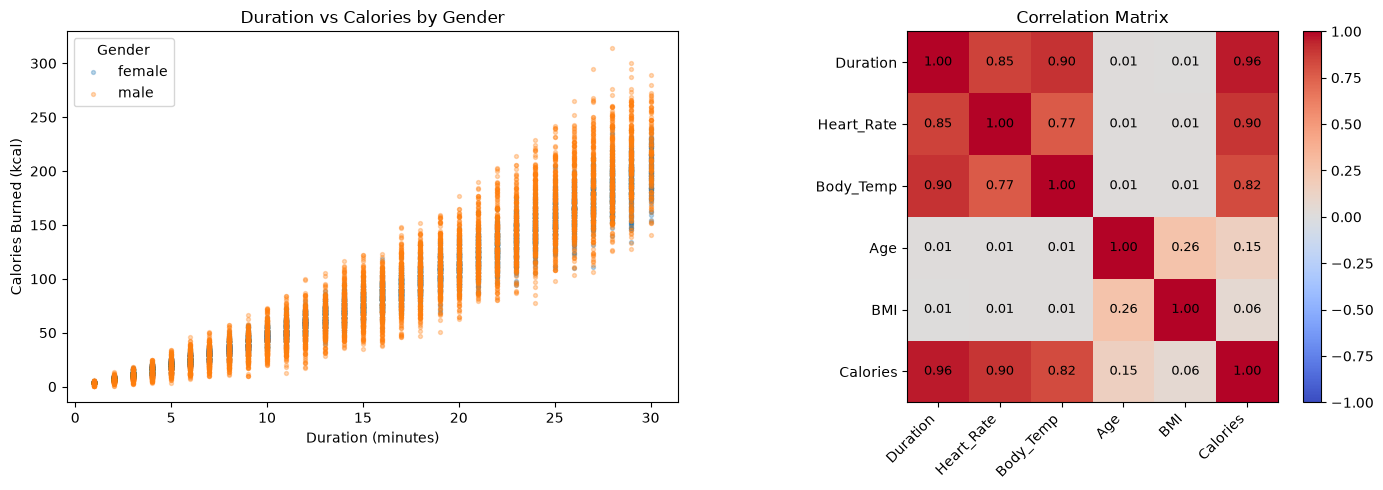

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for gender, group in df.groupby("Gender", observed=True):
    ax1.scatter(group["Duration"], group["Calories"],s=8, alpha=0.3, label=str(gender))
ax1.set_xlabel("Duration (minutes)")
ax1.set_ylabel("Calories Burned (kcal)")
ax1.set_title("Duration vs Calories by Gender")
ax1.legend(title="Gender")

im = ax2.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax2.set_xticks(range(len(corr.columns)))
ax2.set_yticks(range(len(corr.columns)))
ax2.set_xticklabels(corr.columns, rotation=45, ha="right")
ax2.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax2.text(j, i, f"{corr.values[i, j]:.2f}",ha="center", va="center", fontsize=9)

ax2.set_title("Correlation Matrix")

fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("../reports/figures/q1_duration_vs_calories.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Q1 Result — Duration & Heart_Rate vs Calories

**Correlations with `Calories` (Pearson):**

| Variable | r |
|---|---:|
| Duration | 0.955 |
| Heart_Rate | 0.898 |
| Body_Temp | 0.825 |
| Age | 0.154 |
| BMI | 0.056 |

- Strongest predictor: `Duration` (r = 0.955, **very strong positive**).
- `Heart_Rate` (r = 0.898) and `Body_Temp` (r = 0.825) are also strong.
- `Age` shows a weak positive correlation (r = 0.154) and `BMI` a negligible one (r = 0.056).

**Mean Calories by duration bucket:**

| Duration | Mean (kcal) | Median | n |
|---|---:|---:|---:|
| 1–10 min | 24.12 | 22.0 | 4874 |
| 11–20 min | 81.44 | 79.0 | 5254 |
| 21–30 min | 163.72 | 161.0 | 4872 |

- Mean calories increased monotonically with duration.
- The jump from 1–10 to 21–30 min is roughly 6.8×.

**Overlap between predictors:**
`Duration` and `Heart_Rate` are also strongly correlated with each other,
so their individual contributions to `Calories` overlap.

**Compared to my hypothesis:**
Confirmed — I expected `Duration` to have the strongest positive 
correlation with `Calories`, and the result (r = 0.955) matches.

**Note on causality:** These are observational correlations. 
The data does not establish that longer duration *causes* more calories 
to be burned; only that they are strongly associated.

In [9]:
gender_summary = (
    df.groupby("Gender", observed=True)
    .agg(
        cpm_mean=("Calories_per_Minute", "mean"),
        cpm_median=("Calories_per_Minute", "median"),
        cpm_std=("Calories_per_Minute", "std"),
        avg_duration=("Duration", "mean"),
        n=("User_ID", "count"),
    ) .round(3)
)
gender_summary

,cpm_mean,cpm_median,cpm_std,avg_duration,n
Gender,,,,,
female,5.210,5.208,1.079,15.502,7553
male,5.192,5.182,1.689,15.559,7447


In [10]:
age_summary = (
    df.groupby("Age_Group", observed=True)
    .agg(
        cpm_mean=("Calories_per_Minute", "mean"),
        cpm_median=("Calories_per_Minute", "median"),
        cpm_std=("Calories_per_Minute", "std"),
        avg_duration=("Duration", "mean"),
        n=("User_ID", "count"),
    ).round(3)
)
age_summary

,cpm_mean,cpm_median,cpm_std,avg_duration,n
Age_Group,,,,,
20-29,4.570,4.615,1.294,15.418,4387
30-39,4.920,4.933,1.280,15.503,3115
40-49,5.250,5.294,1.261,15.535,2394
50-59,5.576,5.556,1.273,15.508,2011
60+,6.098,6.000,1.362,15.729,3093


In [11]:
cpm_pivot = df.pivot_table(
    values="Calories_per_Minute",
    index="Age_Group",
    columns="Gender",
    aggfunc="mean",
    observed=True,
).round(3)
cpm_pivot

Gender,female,male
Age_Group,,
20-29,4.882,4.248
30-39,5.045,4.795
40-49,5.226,5.274
50-59,5.468,5.689
60+,5.661,6.535


In [12]:
count_crosstab = pd.crosstab(df["Age_Group"], df["Gender"])
count_crosstab

Gender,female,male
Age_Group,,
20-29,2223,2164
30-39,1553,1562
40-49,1208,1186
50-59,1024,987
60+,1545,1548


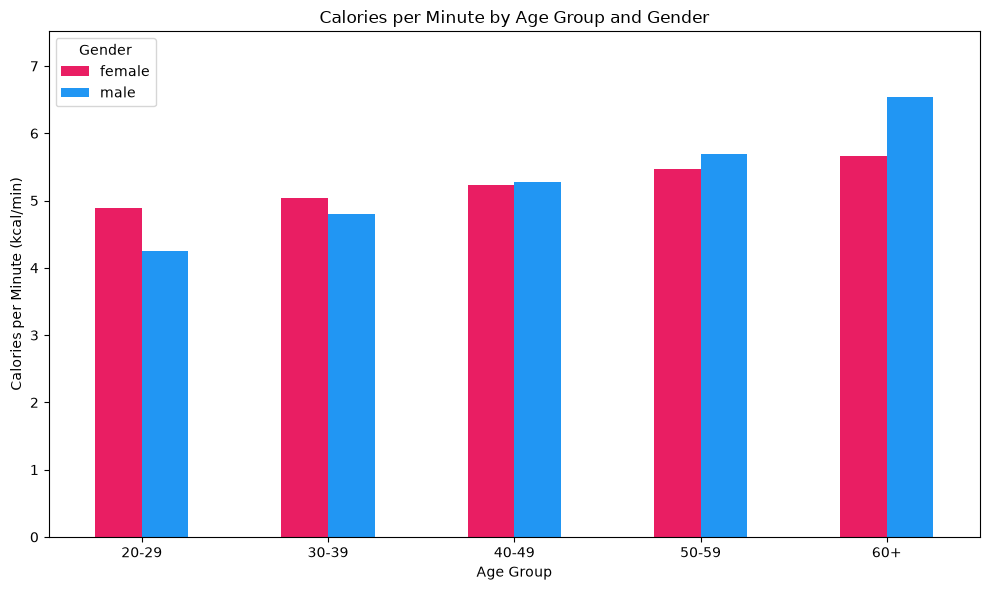

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

cpm_pivot.plot(kind="bar", ax=ax, color=["#E91E63", "#2196F3"])

ax.set_xlabel("Age Group")
ax.set_ylabel("Calories per Minute (kcal/min)")
ax.set_title("Calories per Minute by Age Group and Gender")
ax.set_ylim(0, cpm_pivot.max().max() * 1.15)
ax.legend(title="Gender")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../reports/figures/q2_gender_age_cpm.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Q2 Result — Calories per Minute by Gender and Age

**By Gender:**

| Gender | cpm_mean | cpm_median | cpm_std | avg_duration | n |
|---|---:|---:|---:|---:|---:|
| female | 5.210 | 5.208 | 1.079 | 15.502 | 7553 |
| male   | 5.192 | 5.182 | 1.689 | 15.559 | 7447 |

- Difference: **0.018 kcal/min** (female is 0.35% higher) — negligible.
- Std dev differs more: males have higher variance (1.69 vs 1.08).
- `avg_duration` is nearly identical (15.50 vs 15.56) → fair comparison.

**By Age Group:**

| Age_Group | cpm_mean | cpm_median | cpm_std | avg_duration | n |
|---|---:|---:|---:|---:|---:|
| 20-29 | 4.570 | 4.615 | 1.294 | 15.418 | 4387 |
| 30-39 | 4.920 | 4.933 | 1.280 | 15.503 | 3115 |
| 40-49 | 5.250 | 5.294 | 1.261 | 15.535 | 2394 |
| 50-59 | 5.576 | 5.556 | 1.273 | 15.508 | 2011 |
| 60+   | 6.098 | 6.000 | 1.362 | 15.729 | 3093 |

- Highest: **60+** (6.098), lowest: **20-29** (4.570).
- Absolute diff: **1.528 kcal/min**, percentage diff: **33.4%**.
- Trend is **monotonically increasing with age**.

**Pivot (Age × Gender):**

| Age_Group | female | male | female − male |
|---|---:|---:|---:|
| 20-29 | 4.882 | 4.248 | +0.634 |
| 30-39 | 5.045 | 4.795 | +0.250 |
| 40-49 | 5.226 | 5.274 | −0.048 |
| 50-59 | 5.468 | 5.689 | −0.221 |
| 60+   | 5.661 | 6.535 | −0.874 |

**Interaction (Age × Gender):**
The gender gap changes sign with age: females are higher by 0.634 kcal/min
at 20–29, the gap closes around 40–49 (−0.048), and males are higher by
0.874 kcal/min at 60+. The near-zero overall gender difference (0.018)
comes from these opposite gaps cancelling out. This is a Simpson-like
effect: the marginal (overall) comparison hides a structured
interaction between age and gender.

**Hypothesis check:**

1. **Younger groups burn more per minute?** — **Rejected.**
   The data shows the opposite: the 60+ group had the highest mean
   (6.098 kcal/min), while the 20–29 group had the lowest (4.570).
   The trend increases monotonically with age.

2. **Males burn more than females?** — Confirmed for 40+,  reversed below 40.
   Overall the gap is negligible (0.018 kcal/min, 0.35%), but this
   is because the sign flips across age groups: females are higher
   below 40, males are higher from 40–49 onward.

**Fair comparison?** Yes — `avg_duration` is within 0.3 min across all
groups, so the cpm comparison is not biased by different workout lengths.

**Causality note:** Observational comparison only. The age-related
pattern could reflect differences in fitness level, workout intensity,
or how the data was recorded — not an effect of age itself. The
age × gender interaction should be treated as an observed association,
not a causal claim.

In [14]:
bmi_summary = (
    df.groupby("BMI_Group", observed=True)
    .agg(
        cpm_mean=("Calories_per_Minute", "mean"),
        cpm_median=("Calories_per_Minute", "median"),
        cpm_std=("Calories_per_Minute", "std"),
        avg_duration=("Duration", "mean"),
        avg_age=("Age", "mean"),
        n=("User_ID", "count"),
    ).round(3)
)
bmi_summary

,cpm_mean,cpm_median,cpm_std,avg_duration,avg_age,n
BMI_Group,,,,,,
Normal,5.089,5.105,1.281,15.492,40.465,9792
Overweight,5.411,5.400,1.617,15.604,47.161,5208


In [15]:
normal_mean = bmi_summary.loc["Normal", "cpm_mean"]
over_mean = bmi_summary.loc["Overweight", "cpm_mean"]

abs_diff = over_mean - normal_mean
pct_diff = abs_diff / normal_mean * 100

print(f"normal cpm_mean:     {normal_mean:.3f}")
print(f"overweight cpm_mean: {over_mean:.3f}")
print(f"absolute diff (OW − N): {abs_diff:+.3f} kcal/min")
print(f"percentage diff:        {pct_diff:+.2f}%")

normal cpm_mean:     5.089
overweight cpm_mean: 5.411
absolute diff (OW − N): +0.322 kcal/min
percentage diff:        +6.33%


In [16]:
bmi_gender = (
    df.groupby(["BMI_Group", "Gender"], observed=True)
    .agg(
        cpm_mean=("Calories_per_Minute", "mean"),
        cpm_median=("Calories_per_Minute", "median"),
        cpm_std=("Calories_per_Minute", "std"),
        avg_duration=("Duration", "mean"),
        avg_age=("Age", "mean"),
        n=("User_ID", "count"),
    ).round(3)
)
bmi_gender

cpm_mean  cpm_median  cpm_std  avg_duration  avg_age     n
BMI_Group  Gender                                                            
Normal     female     5.204       5.200    1.081        15.507   41.771  6945
           male       4.810       4.800    1.638        15.455   37.280  2847
Overweight female     5.273       5.279    1.052        15.447   53.752   608
           male       5.429       5.422    1.676        15.624   46.289  4600

In [17]:
bmi_gender_pivot = bmi_gender["cpm_mean"].unstack()
bmi_gender_pivot

Gender,female,male
BMI_Group,,
Normal,5.204,4.810
Overweight,5.273,5.429


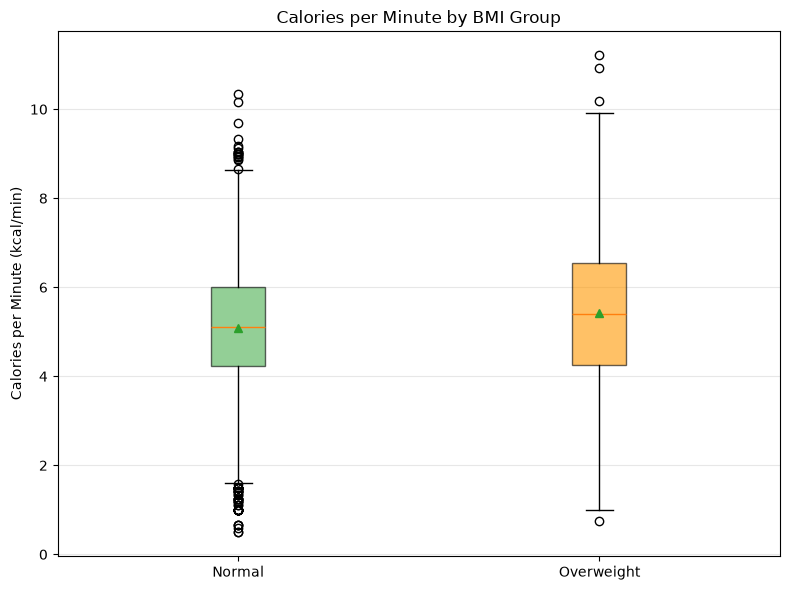

In [18]:
data = [
    df.loc[df["BMI_Group"] == "Normal", "Calories_per_Minute"].values,
    df.loc[df["BMI_Group"] == "Overweight", "Calories_per_Minute"].values,
]

fig, ax = plt.subplots(figsize=(8, 6))

bp = ax.boxplot(
    data,
    tick_labels=["Normal", "Overweight"],
    showmeans=True,
    patch_artist=True,
)

colors = ["#4CAF50", "#FF9800"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel("Calories per Minute (kcal/min)")
ax.set_title("Calories per Minute by BMI Group")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/q3_bmi_group_cpm.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Q3 Result — BMI Group (Normal vs Overweight)

**By BMI Group:**

| BMI_Group | cpm_mean | cpm_median | cpm_std | avg_duration | avg_age | n |
|---|---:|---:|---:|---:|---:|---:|
| Normal | 5.089 | 5.105 | 1.281 | 15.492 | 40.465 | 9792 |
| Overweight | 5.411 | 5.400 | 1.617 | 15.604 | 47.161 | 5208 |

- Absolute diff (Overweight − Normal): **+0.322 kcal/min**
- Percentage diff vs Normal: **+6.33%**

**By BMI_Group × Gender:**

| BMI_Group | female | male | female − male |
|---|---:|---:|---:|
| Normal | 5.204 | 4.810 | +0.394 |
| Overweight | 5.273 | 5.429 | −0.156 |

- The pattern is **not consistent across genders**: for females the gap 
  between Overweight and Normal is small (5.273 − 5.204 = **+0.069**); 
  for males it is much larger (5.429 − 4.810 = **+0.619**). 
  This suggests a BMI × Gender interaction.

**Hypothesis check:**
I expected Overweight individuals to burn slightly more calories 
per minute. —  **Partially supported, but likely confounded.**

- Overweight cpm is 6.33% higher overall, in the direction I expected.
- However, `avg_age` differs substantially between groups 
  (Normal = 40.5, Overweight = 47.2). Since Q2 showed that cpm 
  **increases with age**, part of this gap is likely explained by age 
  rather than BMI. A simple unadjusted comparison overstates the 
  effect of BMI.

**Fair comparison?**
- `avg_duration` is close (15.49 vs 15.60 min) → duration is not a 
  confounder here.
- `avg_age` is **not** close (40.5 vs 47.2). The comparison is 
  therefore **confounded by age**, and the 6.33% gap should not be 
  read as a pure BMI effect.
- Within-gender split shows a different pattern for each gender:
  the Overweight–Normal gap is small for females (+0.069) and much
  larger for males (+0.619). Notably, the Overweight female subgroup
  is both the oldest (avg_age = 53.8) and the smallest (n = 608).
  Since cpm rises with age (from Q2), age would push its cpm up,
  yet its gap to Normal females is only +0.069. So age does not
  explain the small gap here; small sample size or other unmeasured
  factors may.

**Causality note:** Observational comparison only. BMI_Group is a 
constructed variable from Weight and Height, so any difference 
reflects the underlying physiology of these two measurements rather 
than BMI itself as a causal factor. The age imbalance between groups 
also means the observed gap cannot be attributed to BMI alone.

**Scope note:** The dataset only contains `Normal` and `Overweight` 
individuals. No `Underweight` or `Obese` observations are present, 
so no conclusion can be drawn about those categories.

In [19]:
import time
weight_np = df["Weight"].to_numpy()
height_np = df["Height"].to_numpy()

n = len(weight_np)
repeats = 5

loop_times = []
for _ in range(repeats):
    start = time.perf_counter()
    bmi_loop = np.empty(n)
    for i in range(n):
        bmi_loop[i] = weight_np[i] / (height_np[i] / 100) ** 2
    loop_times.append(time.perf_counter() - start)
    
print(f"Python loop: best = {min(loop_times)*1e3:.2f} ms, mean = {np.mean(loop_times)*1e3:.2f} ms")

Python loop: best = 7.68 ms, mean = 8.23 ms


In [20]:
vec_times = []
for _ in range(repeats):
    start = time.perf_counter()
    bmi_vec = weight_np / (height_np / 100) ** 2
    vec_times.append(time.perf_counter() - start)

print(f"NumPy vectorized: best = {min(vec_times)*1e6:.1f} µs, mean = {np.mean(vec_times)*1e6:.1f} µs")

NumPy vectorized: best = 18.8 µs, mean = 41.7 µs


In [21]:
speedup = min(loop_times) / min(vec_times)
print(f"speedup (loop / vectorized): {speedup:.1f}x")
print(f"same results? np.allclose = {np.allclose(bmi_loop, bmi_vec)}")
print(f"max absolute difference: {np.abs(bmi_loop - bmi_vec).max():.2e}")

speedup (loop / vectorized): 408.6x
same results? np.allclose = True
max absolute difference: 0.00e+00


In [22]:
numeric_cols = ["Duration", "Heart_Rate", "Body_Temp", "Calories"]
X = df[numeric_cols].to_numpy()

X_mean = X.mean(axis=0)
X_std  = X.std(axis=0)
X_stdz = (X - X_mean) / X_std

print("X shape:      ", X.shape)
print("X_mean shape: ", X_mean.shape)
print("Result shape: ", X_stdz.shape)
print()
print("Check: mean ≈ 0 and std ≈ 1 for each column")
print("means:", np.round(X_stdz.mean(axis=0), 6))
print("stds: ", np.round(X_stdz.std(axis=0),  6))

X shape:       (15000, 4)
X_mean shape:  (4,)
Result shape:  (15000, 4)

Check: mean ≈ 0 and std ≈ 1 for each column
means: [ 0. -0. -0. -0.]
stds:  [1. 1. 1. 1.]


### NumPy Vectorization Benchmark

**Results (best of 5 runs, 15,000 rows):**

| Method | Best time | Mean time |
|---|---:|---:|
| Python loop | 7.52 ms | 7.78 ms |
| NumPy vectorized | 16.4 µs | 40.2 µs |

Speedup: **458.4×**. `np.allclose` → **True** (max diff = 0.00e+00).

**Why faster:** No per-iteration interpreter overhead, C-level loops
on contiguous memory, and broadcasting (no explicit loops).
The trade-off is temporary array allocation, negligible at 15k rows.

## Key Findings

All numbers below come from the outputs above (n = 15,000 workout sessions).

1. **Workout duration is the strongest correlate of total calories.**
   `Duration` correlates with `Calories` at r = 0.955 (`Heart_Rate` r = 0.898, `Body_Temp` r = 0.825; `Age` r = 0.154, `BMI` r = 0.056).
   Mean calories rise from 24.1 kcal (1–10 min) to 81.4 kcal (11–20 min) to 163.7 kcal (21–30 min), about 6.8× from the shortest to the longest bucket.

2. **Calories burned per minute increase steadily with age.**
   The mean goes from 4.570 kcal/min (age 20–29) to 6.098 kcal/min (60+), a difference of +1.528 kcal/min (+33.4%), and it increases in every one of the five age groups.
   Average workout length is almost the same across groups (15.4–15.7 min), so this is not a duration artifact.

3. **The overall gender difference hides an age × gender interaction.**
   Overall, females and males are almost identical (5.210 vs 5.192 kcal/min, a 0.018 gap). By age group the gap changes sign:
   females are higher by 0.634 kcal/min at 20–29, the gap closes around 40–49 (−0.048), and males are higher by 0.874 kcal/min at 60+.
   The near-zero overall gap comes from these opposite differences cancelling out.

4. **Overweight users burn more per minute than Normal-BMI users, but the comparison is confounded by age.**
   Overweight: 5.411 kcal/min, Normal: 5.089 kcal/min (+0.322, +6.33%).
   However, the Overweight group is about 6.7 years older on average (47.2 vs 40.5), and Finding 2 shows that per-minute burn rises with age, so this gap should not be read as a pure BMI effect.

### Practical observations

- Within this dataset, session length is by far the variable most strongly associated with total calories: 21–30 minute sessions averaged 163.7 kcal versus 24.1 kcal for sessions of 10 minutes or less. This is a descriptive pattern, not medical or training advice.
- When comparing groups, do not rely on overall averages. Gender should be compared within age groups, and BMI groups should be compared after accounting for age (for example, within each age group).

### Limitations

These results are observational and descriptive: they show associations in this particular dataset, not causes. The data source and collection method are not documented, and several features suggest the sample may not represent a typical real-world population: body temperature is around 40 °C on average during exercise, BMI spans only about 19 to 29 (there are no Underweight or Obese participants), durations are whole minutes between 1 and 30, and ages are 20–79. The findings should therefore not be generalized to other populations, and no conclusion is possible about Underweight or Obese groups. The Overweight female subgroup is small (n = 608), so its averages are less reliable than the others. Correlations are Pearson (linear) coefficients, while the relation between duration and calories looks slightly curved. Differences are reported with descriptive statistics only, without significance tests, confidence intervals, or models that adjust for several variables at once. In a health-related topic, a correlation must never be read as evidence that one variable causes another.